# Short-Horizon Multi-Step Trajectory Prediction (t + Ts)

Notebook này thực hiện dự đoán điểm ở tương lai (t + Ts) bằng cách sử dụng T bước lịch sử. Notebook bao gồm:
1. Phân tích Ablation Study để tìm số layer tối ưu cho GRU.
2. So sánh RNN, LSTM, GRU với cấu hình layer tối ưu.

## 1. Cấu hình và Thiết lập Môi trường

In [ ]:
import numpy as np
import pandas as pd
import pickle
import time
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GRU, LSTM, SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ===== CẤU HÌNH =====
Ts = 1               # Prediction horizon: dự đoán điểm t + Ts
T = 20               # Input history length
NUM_FEATURES = 6     # x, y, z, vx, vy, vz
PRED_STEPS = 171     # Số bước dự đoán mỗi quỹ đạo
SEQUENCE_LENGTH = T + PRED_STEPS  # = 191
SAMPLING_FREQ = 16   # Hz
BATCH_SIZE = 64
EPOCHS = 80
NUM_RUNS = 1         # Số lần chạy mỗi model để lấy trung bình (có thể set 1 để test)

def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

# ===== AUTO-DETECT COLAB vs LOCAL =====
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/GRU-Model/'
except ImportError:
    IN_COLAB = False
    BASE_PATH = '.'  # Đường dẫn local

TRAIN_DATA_PATH = os.path.join(BASE_PATH, 'train_trajectories.csv')
TEST_DATA_PATH  = os.path.join(BASE_PATH, 'test_trajectories.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load và Tiền xử lý dữ liệu

Sử dụng `create_data_multistep()` để tạo bộ dữ liệu. Ở đây đầu ra (target) sẽ là điểm cách xa `Ts` bước.

In [ ]:
def load_data(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    df = pd.read_csv(file_path)
    return df[['x', 'y', 'z']].values if 'x' in df.columns else df[['X', 'Y', 'Z']].values

def create_data_multistep(data, T, Ts, sequence_length):
    X, y = [], []
    num_trajectories = len(data) // sequence_length
    print(f"Số lượng quỹ đạo: {num_trajectories}")
    for i in range(num_trajectories):
        trajectory = data[i*sequence_length : (i+1)*sequence_length]
        if trajectory.shape != (sequence_length, 3): continue
        velocity = np.zeros_like(trajectory)
        velocity[1:] = trajectory[1:] - trajectory[:-1]
        velocity[0] = 0
        traj_features = np.hstack([trajectory, velocity])
        for j in range(sequence_length - Ts + 1):
            if j < T:
                num_zeros = T - j
                zero_padding = np.zeros((num_zeros, 6))
                if j > 0:
                    real_points = traj_features[0:j]
                    input_sequence = np.vstack([zero_padding, real_points])
                else:
                    input_sequence = zero_padding
            else:
                input_sequence = traj_features[j-T:j]
            output_point = trajectory[j + Ts - 1]
            X.append(input_sequence)
            y.append(output_point)
    return np.array(X), np.array(y)

def fit_scalers(X, y):
    scaler_x = {'x': MinMaxScaler(), 'y': MinMaxScaler(), 'z': MinMaxScaler(), 'vx': MinMaxScaler(), 'vy': MinMaxScaler(), 'vz': MinMaxScaler()}
    scaler_y = {'x': MinMaxScaler(), 'y': MinMaxScaler(), 'z': MinMaxScaler()}
    scaler_x['x'].fit(X[:, :, 0].reshape(-1, 1))
    scaler_x['y'].fit(X[:, :, 1].reshape(-1, 1))
    scaler_x['z'].fit(X[:, :, 2].reshape(-1, 1))
    scaler_x['vx'].fit(X[:, :, 3].reshape(-1, 1))
    scaler_x['vy'].fit(X[:, :, 4].reshape(-1, 1))
    scaler_x['vz'].fit(X[:, :, 5].reshape(-1, 1))
    scaler_y['x'].fit(y[:, 0].reshape(-1, 1))
    scaler_y['y'].fit(y[:, 1].reshape(-1, 1))
    scaler_y['z'].fit(y[:, 2].reshape(-1, 1))
    return scaler_x, scaler_y

def transform_data(X, y, scaler_x, scaler_y):
    num_samples, T, _ = X.shape
    X_scaled = np.zeros_like(X)
    X_scaled[:, :, 0] = scaler_x['x'].transform(X[:, :, 0].reshape(-1, 1)).reshape(num_samples, T)
    X_scaled[:, :, 1] = scaler_x['y'].transform(X[:, :, 1].reshape(-1, 1)).reshape(num_samples, T)
    X_scaled[:, :, 2] = scaler_x['z'].transform(X[:, :, 2].reshape(-1, 1)).reshape(num_samples, T)
    X_scaled[:, :, 3] = scaler_x['vx'].transform(X[:, :, 3].reshape(-1, 1)).reshape(num_samples, T)
    X_scaled[:, :, 4] = scaler_x['vy'].transform(X[:, :, 4].reshape(-1, 1)).reshape(num_samples, T)
    X_scaled[:, :, 5] = scaler_x['vz'].transform(X[:, :, 5].reshape(-1, 1)).reshape(num_samples, T)
    y_scaled = None
    if y is not None:
        y_scaled = np.zeros_like(y)
        y_scaled[:, 0] = scaler_y['x'].transform(y[:, 0].reshape(-1, 1)).ravel()
        y_scaled[:, 1] = scaler_y['y'].transform(y[:, 1].reshape(-1, 1)).ravel()
        y_scaled[:, 2] = scaler_y['z'].transform(y[:, 2].reshape(-1, 1)).ravel()
    return X_scaled, y_scaled

# Load data
print("Đang tải dữ liệu...")
raw_train = load_data(TRAIN_DATA_PATH)
raw_test = load_data(TEST_DATA_PATH)

print("Đang tạo sequence (Ts={})...".format(Ts))
X_train_raw, y_train_raw = create_data_multistep(raw_train, T, Ts, SEQUENCE_LENGTH)
X_test_raw, y_test_raw = create_data_multistep(raw_test, T, Ts, SEQUENCE_LENGTH)

# Chia validation set (15%) từ train set
indices = np.arange(len(X_train_raw))
idx_train, idx_val = train_test_split(indices, test_size=0.1765, random_state=42, shuffle=True) # 0.1765 * 0.85 = ~15% của tổng data nếu gộp cả test

X_train, y_train = X_train_raw[idx_train], y_train_raw[idx_train]
X_val, y_val = X_train_raw[idx_val], y_train_raw[idx_val]
X_test, y_test = X_test_raw, y_test_raw

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

print("Fitting scalers...")
scaler_x, scaler_y = fit_scalers(X_train, y_train)

X_train_s, y_train_s = transform_data(X_train, y_train, scaler_x, scaler_y)
X_val_s, y_val_s = transform_data(X_val, y_val, scaler_x, scaler_y)
X_test_s, y_test_s = transform_data(X_test, y_test, scaler_x, scaler_y)

Đang tải dữ liệu...
Đang tạo sequence (Ts=1)...
Số lượng quỹ đạo: 306
Số lượng quỹ đạo: 54
X_train: (48130, 20, 6), y_train: (48130, 3)
X_val: (10316, 20, 6), y_val: (10316, 3)
X_test: (10314, 20, 6), y_test: (10314, 3)
Fitting scalers...


## 3. Hàm tạo Model (Functional API)

In [ ]:
def build_model(model_type, input_shape, num_layers=2, units=64):
    LayerClass = {'rnn': SimpleRNN, 'lstm': LSTM, 'gru': GRU}[model_type.lower()]
    inputs = Input(shape=input_shape, name='input_sequence')
    x = inputs

    for i in range(num_layers):
        return_sequences = (i < num_layers - 1)
        x = LayerClass(units, activation='tanh', return_sequences=return_sequences)(x)
        x = Dropout(0.2)(x)

    output = Dense(3, name='position_output')(x)
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    return model

def get_model_size(model):
    temp_path = 'temp_model.h5'
    model.save(temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    if os.path.exists(temp_path): os.remove(temp_path)
    return size_mb

def count_parameters(model):
    trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    return trainable, non_trainable

## 4. Pipeline Training (So sánh Model/Ablation)

In [ ]:
def run_study(study_configs, X_train, y_train, X_val, y_val, X_test, y_test, epochs=100, batch_size=32, num_runs=3):
    input_shape = (X_train.shape[1], X_train.shape[2])
    results = []
    models_dict = {}
    histories_dict = {}

    for config in study_configs:
        name = config['name']
        model_type = config['model_type']
        num_layers = config['num_layers']

        print(f"\n{'='*80}")
        print(f"CONFIGURATION: {name}")
        print(f"{'='*80}")

        run_metrics = {
            'test_loss': [], 'test_mae': [],
            'best_val_loss': [], 'best_val_mae': [],
            'best_train_loss': [],
            'training_time': [], 'inference_time': []
        }

        for run in range(num_runs):
            print(f"--- Run {run+1}/{num_runs} ---")
            set_seed(42 + run)

            model = build_model(model_type, input_shape, num_layers, units=128)

            if run == 0:
                trainable, non_trainable = count_parameters(model)
                total_params = trainable + non_trainable

            early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0)

            start_time = time.time()
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                batch_size=batch_size,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            training_time = time.time() - start_time
            print(f"Training Time: {training_time:.2f}s")

            eval_results = model.evaluate(X_test, y_test, verbose=0, batch_size=batch_size)
            test_loss, test_mae = eval_results[0], eval_results[1]
            print(f"Test Loss: {test_loss:.6f} | Test MAE: {test_mae:.6f}")

            test_samples = X_test[:100]  # Simulate online inference (batch_size=1)
            if len(test_samples) > 0:
                _ = model.predict(test_samples[0:1], verbose=0)
                infer_start = time.time()
                for i in range(len(test_samples)):
                    _ = model.predict(test_samples[i:i+1], verbose=0)
                inference_time = (time.time() - infer_start) / len(test_samples) * 1000
            else:
                inference_time = 0

            run_metrics['test_loss'].append(test_loss)
            run_metrics['test_mae'].append(test_mae)

            val_loss_hist = history.history['val_loss']
            best_epoch_idx = np.argmin(val_loss_hist)
            run_metrics['best_val_loss'].append(val_loss_hist[best_epoch_idx])
            run_metrics['best_val_mae'].append(history.history['val_mae'][best_epoch_idx])
            run_metrics['best_train_loss'].append(history.history['loss'][best_epoch_idx])
            run_metrics['training_time'].append(training_time)
            run_metrics['inference_time'].append(inference_time)

            if run == num_runs - 1:
                models_dict[name] = model
                histories_dict[name] = history

        avg_result = {
            'name': name,
            'model_type': model_type,
            'num_layers': num_layers,
            'total_params': total_params,
            'test_loss': np.mean(run_metrics['test_loss']),
            'test_mae': np.mean(run_metrics['test_mae']),
            'train_loss': np.mean(run_metrics['best_train_loss']),
            'val_loss': np.mean(run_metrics['best_val_loss']),
            'val_mae': np.mean(run_metrics['best_val_mae']),
            'training_time_s': np.mean(run_metrics['training_time']),
            'inference_time_ms': np.mean(run_metrics['inference_time']),
            'model_size_mb': get_model_size(model)
        }
        results.append(avg_result)
        print(f"✅ AVG RESULT ({name}):")
        print(f"   Test Loss: {avg_result['test_loss']:.6f}, MAE: {avg_result['test_mae']:.6f}")
        print(f"   Val Loss:  {avg_result['val_loss']:.6f}, MAE: {avg_result['val_mae']:.6f}")

    return pd.DataFrame(results), models_dict, histories_dict

def visualize_results(results_df, histories_dict, title_prefix=""):
    fig = plt.figure(figsize=(20, 12))
    names = results_df['name'].values
    x = np.arange(len(names))

    # 1. Total Loss (Train vs Val vs Test)
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(x, results_df['train_loss'], marker='o', label='Train Loss', color='blue', linestyle='--')
    ax1.plot(x, results_df['val_loss'], marker='s', label='Val Loss', color='green')
    ax1.plot(x, results_df['test_loss'], marker='^', label='Test Loss', color='red')
    ax1.set_xticks(x)
    ax1.set_xticklabels(names)
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_title(f'{title_prefix} Loss Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. MAE (Val vs Test)
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(x, results_df['val_mae'], marker='s', label='Val MAE', color='green')
    ax2.plot(x, results_df['test_mae'], marker='^', label='Test MAE', color='red')
    ax2.set_xticks(x)
    ax2.set_xticklabels(names)
    ax2.set_title(f'{title_prefix} MAE Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Validation History
    ax3 = plt.subplot(2, 3, 3)
    for name, history in histories_dict.items():
        if 'val_loss' in history.history:
            ax3.plot(history.history['val_loss'], label=f'{name}')
    ax3.set_title(f'{title_prefix} Validation Loss History')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('Val Loss')
    ax3.legend()
    ax3.grid(True)

    # 4. Inference Time
    ax4 = plt.subplot(2, 3, 4)
    bars_inf = ax4.bar(x, results_df['inference_time_ms'], color='lightgreen')
    ax4.set_xticks(x)
    ax4.set_xticklabels(names)
    ax4.set_title('Inference Speed (ms)')
    for bar in bars_inf:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

    # 5. Model Size
    ax5 = plt.subplot(2, 3, 5)
    bars_size = ax5.bar(x, results_df['model_size_mb'], color='plum')
    ax5.set_xticks(x)
    ax5.set_xticklabels(names)
    ax5.set_title('Model Size (MB)')
    for bar in bars_size:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', ha='center', va='bottom')

    # 6. Training Time
    ax6 = plt.subplot(2, 3, 6)
    bars_time = ax6.bar(x, results_df['training_time_s'], color='lightblue')
    ax6.set_xticks(x)
    ax6.set_xticklabels(names)
    ax6.set_title('Training Time (s)')
    for bar in bars_time:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(f'{title_prefix.replace(" ", "_").lower()}_results.png')
    plt.show()

## 5. Ablation Study - Số Layer của mô hình GRU
Khảo sát số layer từ 1 đến 5 để tìm ra cấu hình tốt nhất.


CONFIGURATION: GRU_1L
--- Run 1/1 ---
Training Time: 409.90s
Test Loss: 0.000012 | Test MAE: 0.001627


✅ AVG RESULT (GRU_1L):
   Test Loss: 0.000012, MAE: 0.001627
   Val Loss:  0.000016, MAE: 0.001696

CONFIGURATION: GRU_2L
--- Run 1/1 ---
Training Time: 498.97s
Test Loss: 0.000017 | Test MAE: 0.002034


✅ AVG RESULT (GRU_2L):
   Test Loss: 0.000017, MAE: 0.002034
   Val Loss:  0.000021, MAE: 0.002130

CONFIGURATION: GRU_3L
--- Run 1/1 ---
Training Time: 629.39s
Test Loss: 0.000019 | Test MAE: 0.002300


✅ AVG RESULT (GRU_3L):
   Test Loss: 0.000019, MAE: 0.002300
   Val Loss:  0.000023, MAE: 0.002391

CONFIGURATION: GRU_4L
--- Run 1/1 ---
Training Time: 726.64s
Test Loss: 0.000014 | Test MAE: 0.002222


✅ AVG RESULT (GRU_4L):
   Test Loss: 0.000014, MAE: 0.002222
   Val Loss:  0.000016, MAE: 0.002327

CONFIGURATION: GRU_5L
--- Run 1/1 ---
Training Time: 897.34s
Test Loss: 0.000014 | Test MAE: 0.002219


✅ AVG RESULT (GRU_5L):
   Test Loss: 0.000014, MAE: 0.002219
   Val Loss:  0.000015, MAE: 0.002247

BẢNG SO SÁNH ABLATION STUDY GRU LAYERS:
  name  test_loss  val_loss  test_mae  val_mae  training_time_s  inference_time_ms  model_size_mb
GRU_1L   0.000012  0.000016  0.001627 0.001696       409.904166           0.230691       0.628906
GRU_2L   0.000017  0.000021  0.002034 0.002130       498.971153           0.419424       1.769547
GRU_3L   0.000019  0.000023  0.002300 0.002391       629.394025           0.524264       2.916153
GRU_4L   0.000014  0.000016  0.002222 0.002327       726.639128           0.409608       4.059647
GRU_5L   0.000014  0.000015  0.002219 0.002247       897.338086           0.475437       5.204094


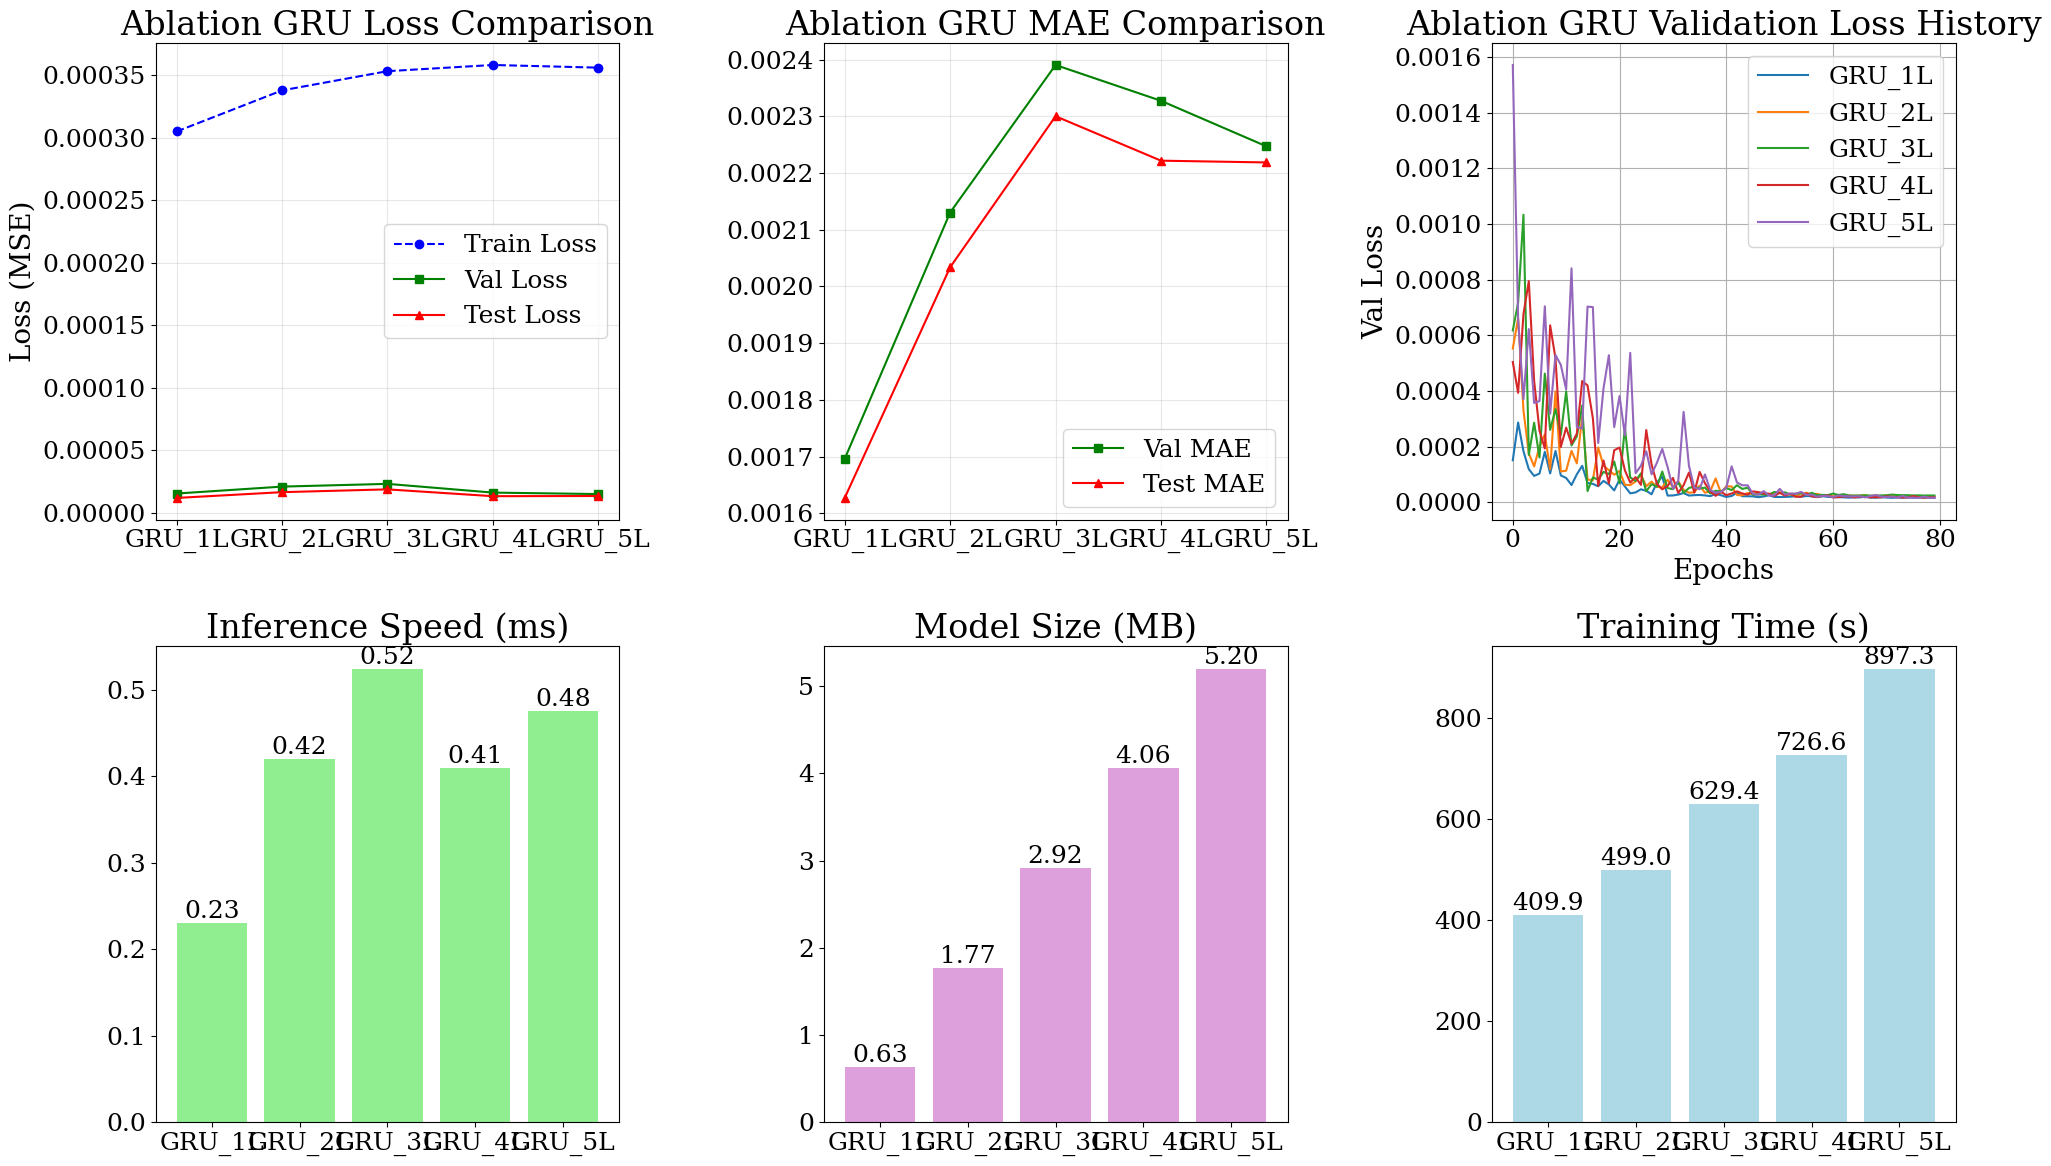


=> SỐ LAYER TỐI ƯU CHO GRU (dựa trên test loss): 1


In [ ]:
ablation_configs = [
    {'name': 'GRU_1L', 'model_type': 'gru', 'num_layers': 1},
    {'name': 'GRU_2L', 'model_type': 'gru', 'num_layers': 2},
    {'name': 'GRU_3L', 'model_type': 'gru', 'num_layers': 3},
    {'name': 'GRU_4L', 'model_type': 'gru', 'num_layers': 4},
    {'name': 'GRU_5L', 'model_type': 'gru', 'num_layers': 5}
]

ablation_df, ablation_models, ablation_histories = run_study(
    ablation_configs, X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s,
    epochs=EPOCHS, batch_size=BATCH_SIZE, num_runs=NUM_RUNS
)

print("\n" + "="*120)
print("BẢNG SO SÁNH ABLATION STUDY GRU LAYERS:")
print("="*120)
cols = ['name', 'test_loss', 'val_loss', 'test_mae', 'val_mae', 'training_time_s', 'inference_time_ms', 'model_size_mb']
print(ablation_df[cols].to_string(index=False))

# Visualization
visualize_results(ablation_df, ablation_histories, "Ablation GRU")

# Chọn số layer tối ưu dựa trên Test Loss
best_gru_idx = ablation_df['test_loss'].idxmin()
optimal_layers = ablation_df.loc[best_gru_idx, 'num_layers']
print(f"\n=> SỐ LAYER TỐI ƯU CHO GRU (dựa trên test loss): {optimal_layers}")

## 6. Model Comparison Study (RNN vs LSTM vs GRU)
Dùng cấu hình layer tối ưu nhất tìm được từ bước trên để đánh giá sự khác biệt giữa các architecture.


CONFIGURATION: RNN
--- Run 1/1 ---
Training Time: 321.21s
Test Loss: 0.000049 | Test MAE: 0.002243


✅ AVG RESULT (RNN):
   Test Loss: 0.000049, MAE: 0.002243
   Val Loss:  0.000070, MAE: 0.002410

CONFIGURATION: LSTM
--- Run 1/1 ---
Training Time: 411.66s
Test Loss: 0.000013 | Test MAE: 0.001663


✅ AVG RESULT (LSTM):
   Test Loss: 0.000013, MAE: 0.001663
   Val Loss:  0.000017, MAE: 0.001736

CONFIGURATION: GRU
--- Run 1/1 ---
Training Time: 386.77s
Test Loss: 0.000013 | Test MAE: 0.001625


✅ AVG RESULT (GRU):
   Test Loss: 0.000013, MAE: 0.001625
   Val Loss:  0.000018, MAE: 0.001714

BẢNG SO SÁNH RNN vs LSTM vs GRU:
name  test_loss  val_loss  test_mae  val_mae  training_time_s  inference_time_ms  model_size_mb
 RNN   0.000049  0.000070  0.002243 0.002410       321.214293           0.554985       0.229492
LSTM   0.000013  0.000017  0.001663 0.001736       411.656031           0.375513       0.823524
 GRU   0.000013  0.000018  0.001625 0.001714       386.774133           0.215230       0.628906


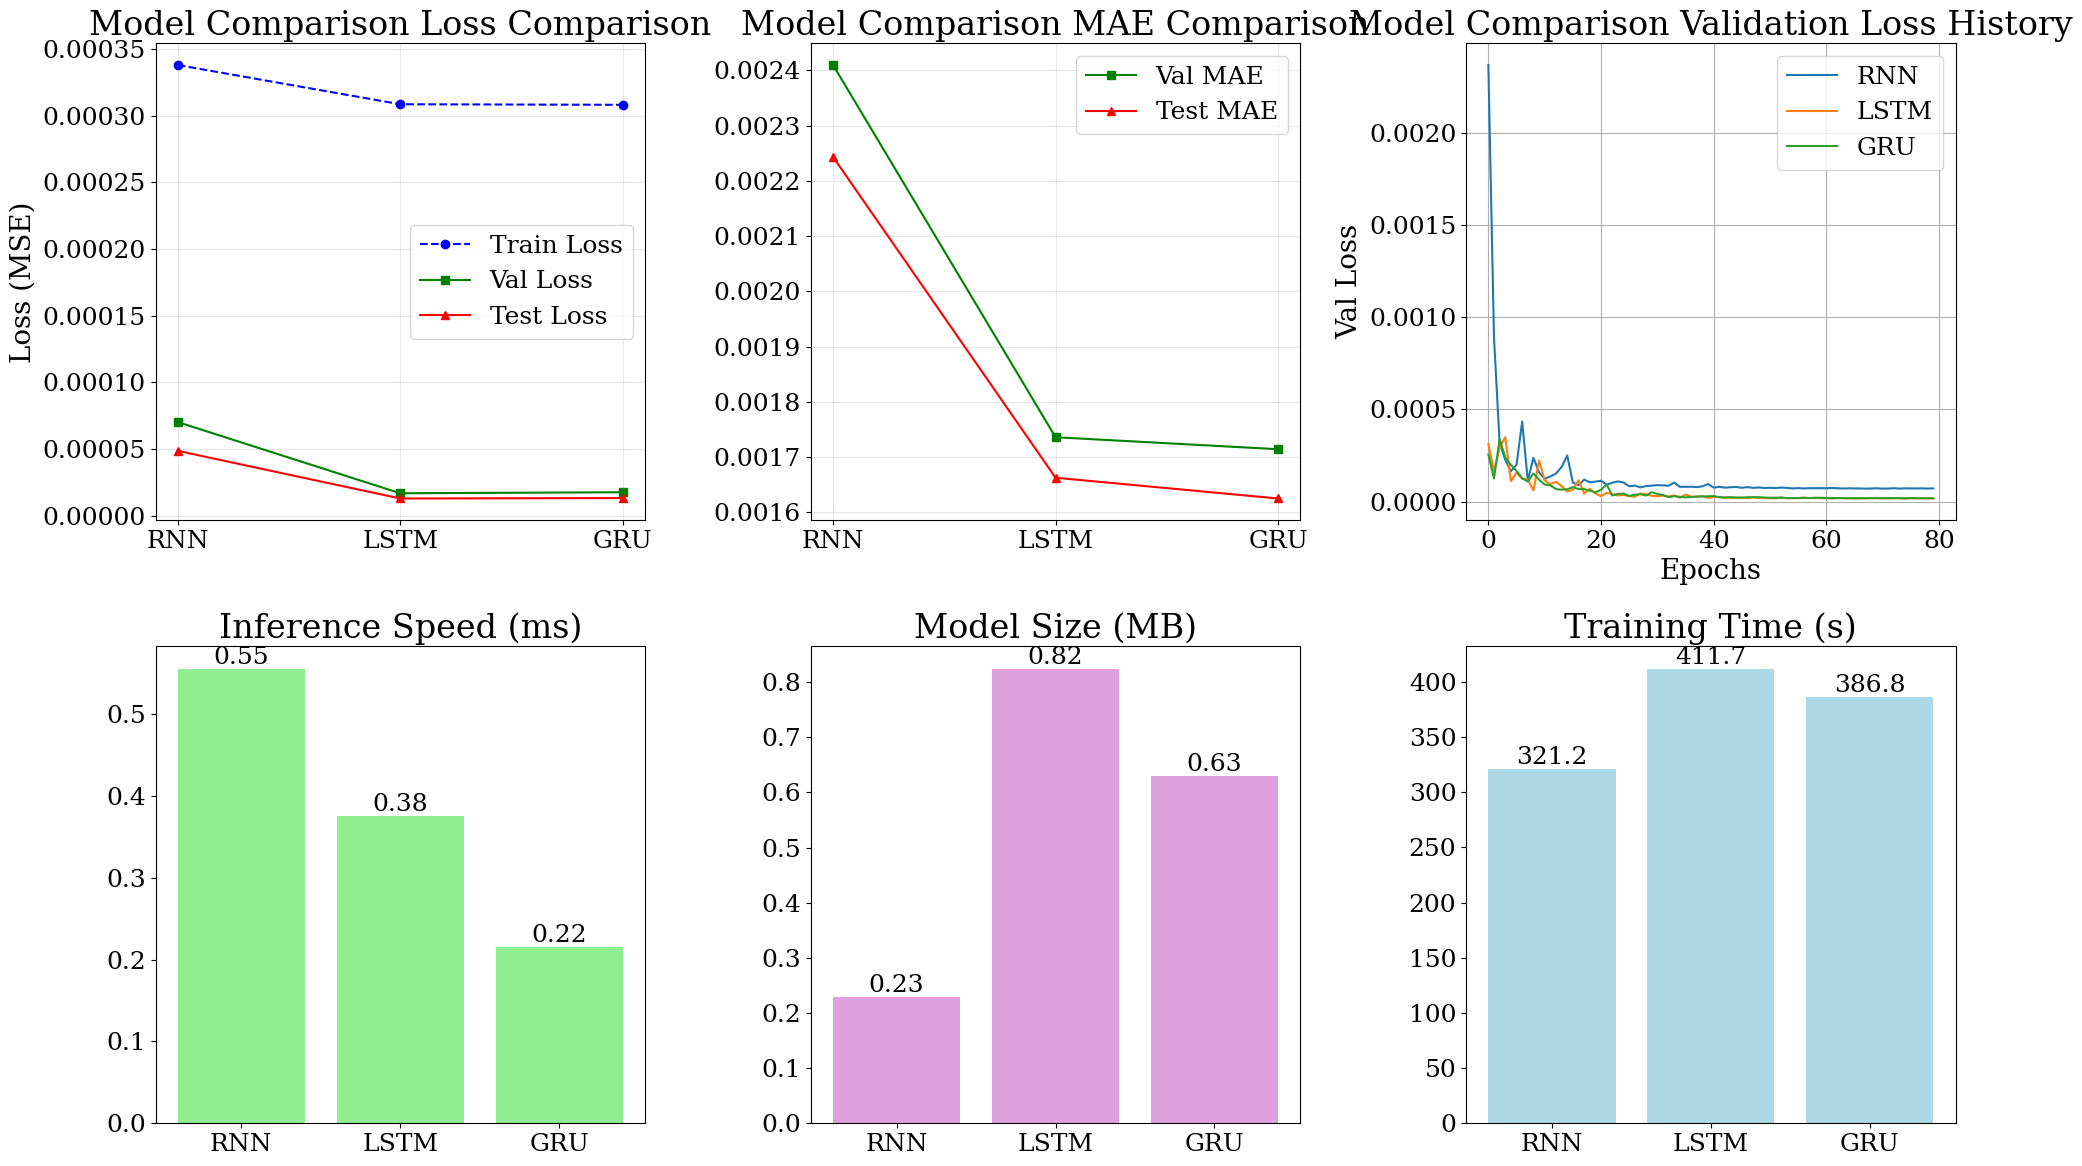

In [ ]:
comparison_configs = [
    {'name': 'RNN', 'model_type': 'rnn', 'num_layers': optimal_layers},
    {'name': 'LSTM', 'model_type': 'lstm', 'num_layers': optimal_layers},
    {'name': 'GRU', 'model_type': 'gru', 'num_layers': optimal_layers}
]

comparison_df, comparison_models, comparison_histories = run_study(
    comparison_configs, X_train_s, y_train_s, X_val_s, y_val_s, X_test_s, y_test_s,
    epochs=EPOCHS, batch_size=BATCH_SIZE, num_runs=NUM_RUNS
)

print("\n" + "="*120)
print("BẢNG SO SÁNH RNN vs LSTM vs GRU:")
print("="*120)
print(comparison_df[cols].to_string(index=False))

# Visualization
visualize_results(comparison_df, comparison_histories, "Model Comparison")

## 7. Đánh giá Online (Assistive Prediction)
Dự đoán t + Ts ở từng bước thời gian dựa vào quỹ đạo Ground Truth.

Vẽ đồ thị dự đoán cho trajectory ID 38 (Ts = 1)
Predicting with RNN...
Predicting with LSTM...
Predicting with GRU...


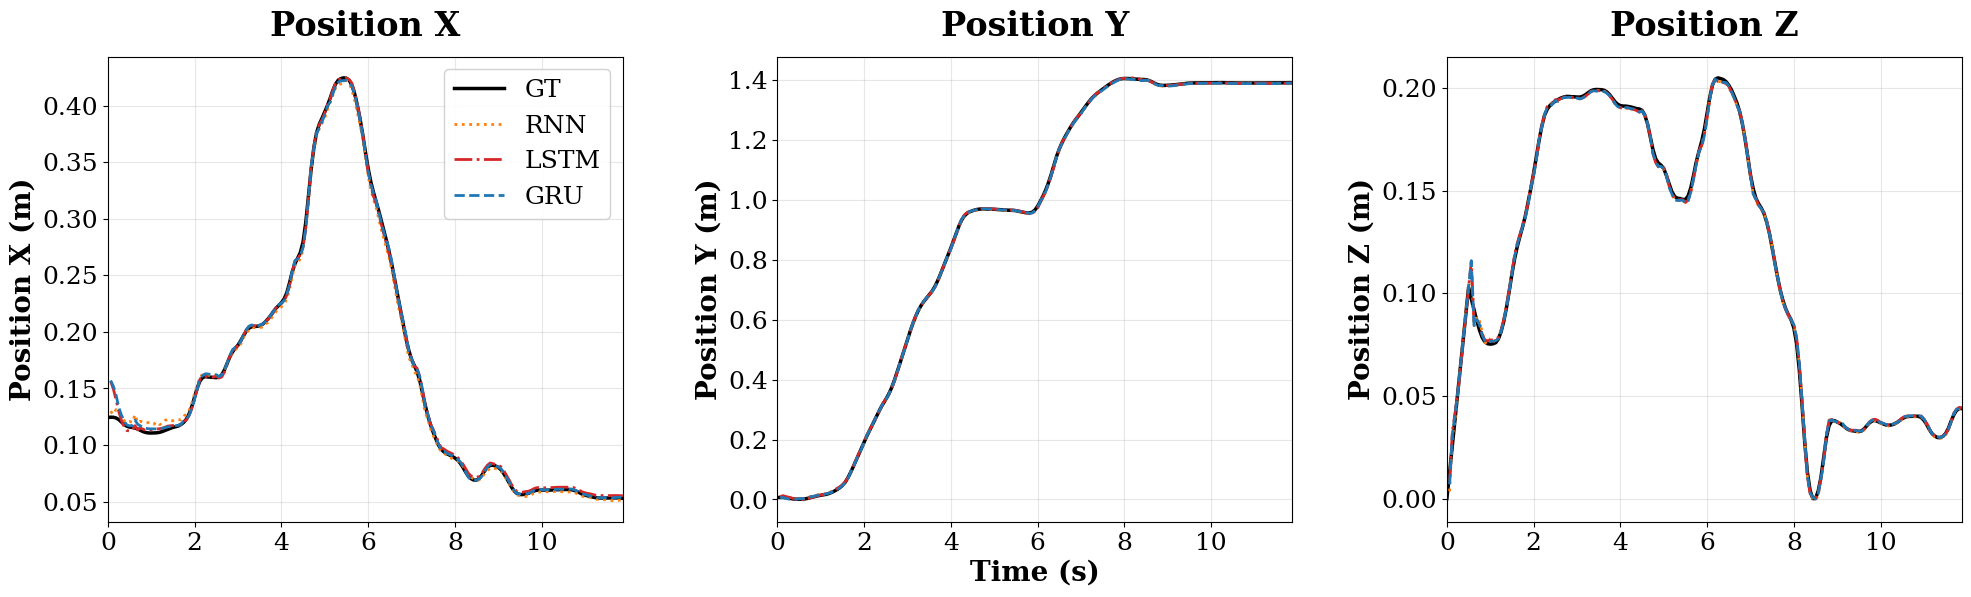

In [ ]:
def predict_assistive_multistep(model, scaler_x, scaler_y, ground_truth_pos, T, Ts):
    predictions = []
    # Initialize input_seq. It should store T timesteps, each with NUM_FEATURES (6).
    input_seq = np.zeros((T, NUM_FEATURES), dtype=np.float32)

    # The first actual ground truth point (position x,y,z) goes into the last timestep of input_seq.
    # Initial velocity for the first point is assumed to be zero.
    input_seq[-1, :3] = ground_truth_pos[0].copy()
    # input_seq[-1, 3:] remains 0 due to np.zeros initialization for velocities.

    # Keep track of the last ground truth position processed to calculate subsequent velocities.
    last_gt_pos = ground_truth_pos[0].copy()

    for i in range(len(ground_truth_pos) - Ts):
        # Use a copy of the current input sequence for prediction
        current_input = input_seq.copy()
        current_input_batch = current_input.reshape(1, T, NUM_FEATURES)

        # Scale the input batch
        input_scaled, _ = transform_data(current_input_batch, None, scaler_x, scaler_y)

        # Make prediction
        pred_scaled = model.predict(input_scaled, verbose=0)

        # Inverse transform the prediction to get actual position (x, y, z)
        pred_pos = np.zeros(3) # The model predicts 3 position values
        pred_pos[0] = scaler_y['x'].inverse_transform(pred_scaled[0, 0].reshape(-1, 1))[0, 0]
        pred_pos[1] = scaler_y['y'].inverse_transform(pred_scaled[0, 1].reshape(-1, 1))[0, 0]
        pred_pos[2] = scaler_y['z'].inverse_transform(pred_scaled[0, 2].reshape(-1, 1))[0, 0]
        predictions.append(pred_pos)

        # Update input_seq for the next iteration:
        # Shift the sequence by one timestep and add the next observed ground truth point
        # along with its calculated velocity.

        # Get the next ground truth position
        next_gt_pos = ground_truth_pos[i + 1].copy()

        # Calculate the velocity based on the current and previous ground truth positions
        current_gt_vel = next_gt_pos - last_gt_pos

        # Create a full feature vector (position + velocity) for the new observed point
        new_feature_point = np.hstack([next_gt_pos, current_gt_vel])

        # Update last_gt_pos for the next iteration's velocity calculation
        last_gt_pos = next_gt_pos.copy()

        # Append the new_feature_point to input_seq, effectively shifting it
        input_seq = np.vstack([input_seq[1:], new_feature_point.reshape(1, NUM_FEATURES)])

    return np.array(predictions)

def plot_trajectory_comparison(gt_pos, predictions_dict, Ts):
    N = len(gt_pos)
    t_full = np.arange(N) / SAMPLING_FREQ
    t_pred = np.arange(Ts, N) / SAMPLING_FREQ  # Predictions start at t + Ts

    plt.rcParams.update({
        'font.size': 18, 'axes.titlesize': 24, 'axes.labelsize': 20,
        'xtick.labelsize': 18, 'ytick.labelsize': 18, 'legend.fontsize': 18,
        'font.family': 'serif'
    })

    labels = ['X', 'Y', 'Z']
    colors = {'GT': 'black', 'GRU': '#1f77b4', 'LSTM': '#d62728', 'RNN': '#ff7f0e'}
    styles = {'GT': '-', 'GRU': '--', 'LSTM': '-.', 'RNN': ':'}

    fig_pos, axs_pos = plt.subplots(1, 3, figsize=(20, 6), sharex=True)
    for i in range(3):
        axs_pos[i].plot(t_full, gt_pos[:, i], label='GT', color=colors['GT'], linewidth=2.5)
        for model_name, p_pos in predictions_dict.items():
            axs_pos[i].plot(t_pred, p_pos[:, i], label=model_name,
                           color=colors.get(model_name, 'green'),
                           linestyle=styles.get(model_name, '--'),
                           linewidth=2)

        axs_pos[i].set_ylabel(f'Position {labels[i]} (m)', fontweight='bold')
        axs_pos[i].set_title(f'Position {labels[i]}', fontweight='bold', pad=15)
        axs_pos[i].grid(True, alpha=0.3)
        axs_pos[i].set_xlim(0, max(t_full))
        if i == 0: axs_pos[i].legend(loc='best', frameon=True, framealpha=0.9)

    axs_pos[1].set_xlabel('Time (s)', fontweight='bold')
    plt.subplots_adjust(left=0.063, bottom=0.127, right=0.99, top=0.902, wspace=0.3, hspace=0.2)
    plt.savefig('trajectory_prediction_comparison.png', dpi=300)
    plt.show()

# Lấy 1 trajectory từ tập test
num_seq_test = len(raw_test) // SEQUENCE_LENGTH
test_trajectories = [raw_test[i*SEQUENCE_LENGTH:(i+1)*SEQUENCE_LENGTH] for i in range(num_seq_test)]

# Chọn ngẫu nhiên 1 trajectory để plot
idx = np.random.randint(len(test_trajectories))
gt_pos = test_trajectories[idx]
print(f"Vẽ đồ thị dự đoán cho trajectory ID {idx} (Ts = {Ts})")

predictions = {}
for name, model in comparison_models.items():
    print(f"Predicting with {name}...")
    p_pos = predict_assistive_multistep(model, scaler_x, scaler_y, gt_pos, T, Ts)
    predictions[name] = p_pos

plot_trajectory_comparison(gt_pos, predictions, Ts)


## 8. Lưu Trữ
Lưu lại model tốt nhất (của bước so sánh) và các DataFrames.

In [ ]:
# Lưu mô hình (Sử dụng định dạng .keras để tránh lỗi Permission trên Drive)
for name, model in comparison_models.items():
    model_path = os.path.join(BASE_PATH, f'{name.lower()}_model_Ts{Ts}.keras')
    try:
        model.save(model_path)
        print(f"Saved model to {model_path}")
    except Exception as e:
        print(f"Lỗi khi lưu {name}: {e}")
        # Backup: lưu vào local nếu Drive lỗi
        local_path = f'{name.lower()}_model_Ts{Ts}.keras'
        model.save(local_path)
        print(f"Đã lưu tạm vào local: {local_path}")

# Lưu Scalers
scaler_x_path = os.path.join(BASE_PATH, f'scaler_x_Ts{Ts}.pkl')
scaler_y_path = os.path.join(BASE_PATH, f'scaler_y_Ts{Ts}.pkl')
with open(scaler_x_path, 'wb') as f:
    pickle.dump(scaler_x, f)
with open(scaler_y_path, 'wb') as f:
    pickle.dump(scaler_y, f)
print("Saved scalers")

# Lưu DataFrames
ablation_df.to_csv(os.path.join(BASE_PATH, f'ablation_results_Ts{Ts}.csv'), index=False)
comparison_df.to_csv(os.path.join(BASE_PATH, f'comparison_results_Ts{Ts}.csv'), index=False)
print("Saved CSV results")

Saved model to /content/drive/MyDrive/GRU-Model/rnn_model_Ts1.keras
Saved model to /content/drive/MyDrive/GRU-Model/lstm_model_Ts1.keras
Saved model to /content/drive/MyDrive/GRU-Model/gru_model_Ts1.keras
Saved scalers
Saved CSV results
